In [17]:
# # Synthetic Data Generation: Improved VAE for Small Data
# 
# ## Using the MNIST Dataset
# 
# This notebook demonstrates **Synthetic Data Generation** with an improved VAE:
# 
# - **Larger latent space** (32 dimensions).
# - **Larger architecture** (512-256-512).
# - **Data augmentation during VAE training**.
# - **Conditional VAE** for class-specific generation.
# - **Quality check** before using synthetic data.
# 
# **Key Question:** Can improved synthetic data help with small data?

# ## 1. Setup and Imports

# %%
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import rotate, shift, zoom

# Set random seed
np.random.seed(42)
torch.manual_seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [19]:
# ## 2. Load MNIST Dataset

print("Loading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='pandas')
X = X.astype(np.float32) / 255.0
y = y.astype(np.int32)

print(f"Dataset shape: X: {X.shape}, y: {y.shape}")

# Split into train and test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train_full.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Loading MNIST dataset...
Dataset shape: X: (70000, 784), y: (70000,)
Training set: 49000 samples
Test set: 21000 samples


Small dataset: 200 samples (20 per class)
Augmented dataset for VAE: 800 samples
VAE training set: 640 samples
VAE validation set: 160 samples
Using device: cpu
VAE parameters: 1,099,600

Training Conditional VAE on small dataset...
Epoch 10: Train Loss = 203.4862, Val Loss = 204.0375
Epoch 20: Train Loss = 181.2016, Val Loss = 184.3262
Epoch 30: Train Loss = 164.7731, Val Loss = 170.1190
Epoch 40: Train Loss = 154.6458, Val Loss = 160.6140
Epoch 50: Train Loss = 145.7326, Val Loss = 153.5131
Epoch 60: Train Loss = 137.9424, Val Loss = 149.2805
Epoch 70: Train Loss = 131.7913, Val Loss = 145.1597
Epoch 80: Train Loss = 126.8416, Val Loss = 143.6590
Epoch 90: Train Loss = 122.9211, Val Loss = 142.1045
Epoch 100: Train Loss = 119.3349, Val Loss = 139.9474
Epoch 110: Train Loss = 116.9621, Val Loss = 139.4419
Epoch 120: Train Loss = 114.6868, Val Loss = 138.3500
Epoch 130: Train Loss = 111.9372, Val Loss = 137.1051
Epoch 140: Train Loss = 110.0563, Val Loss = 136.6344
Epoch 150: Train Los

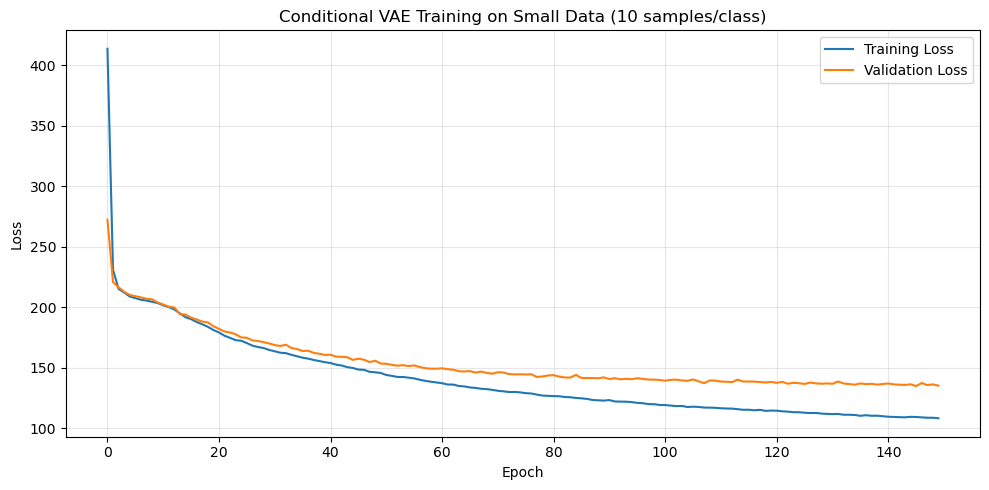

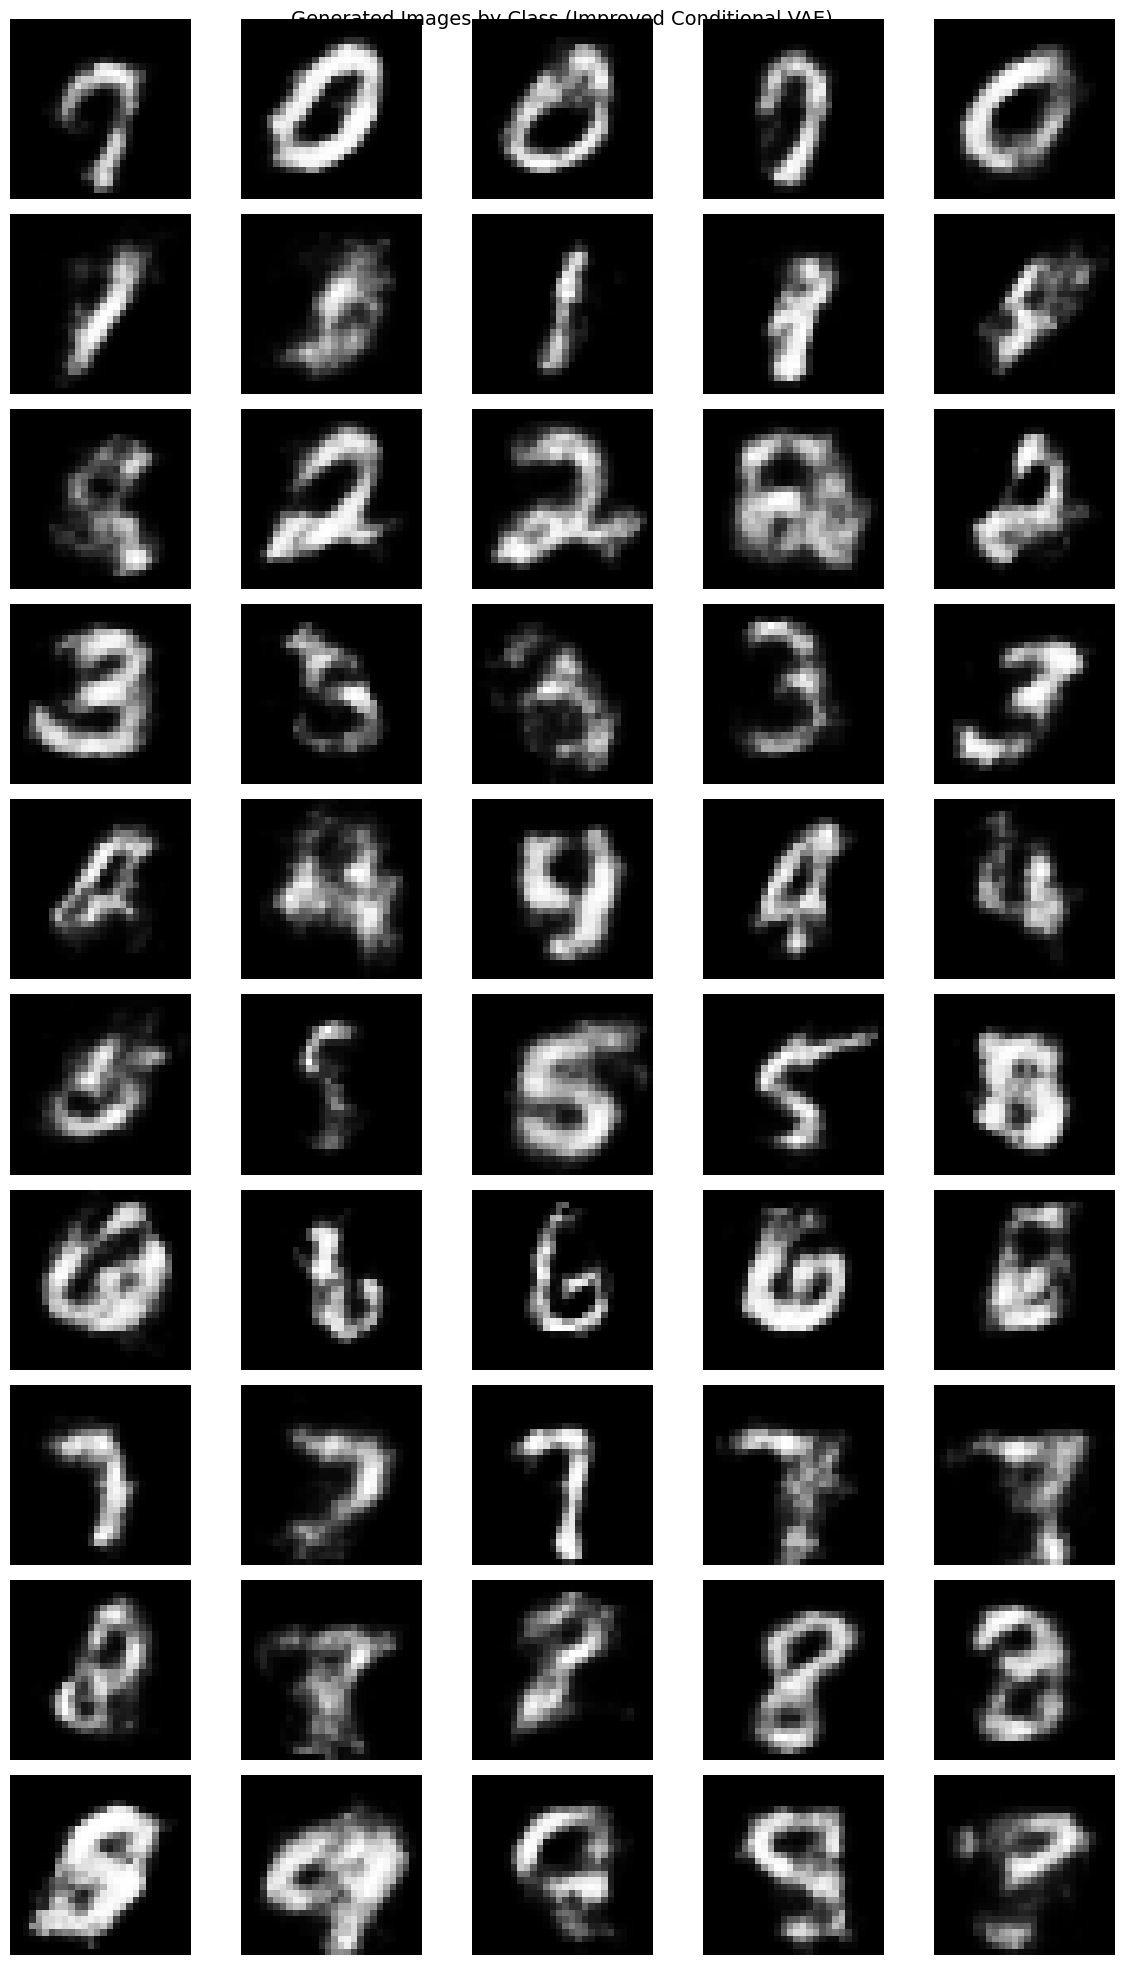

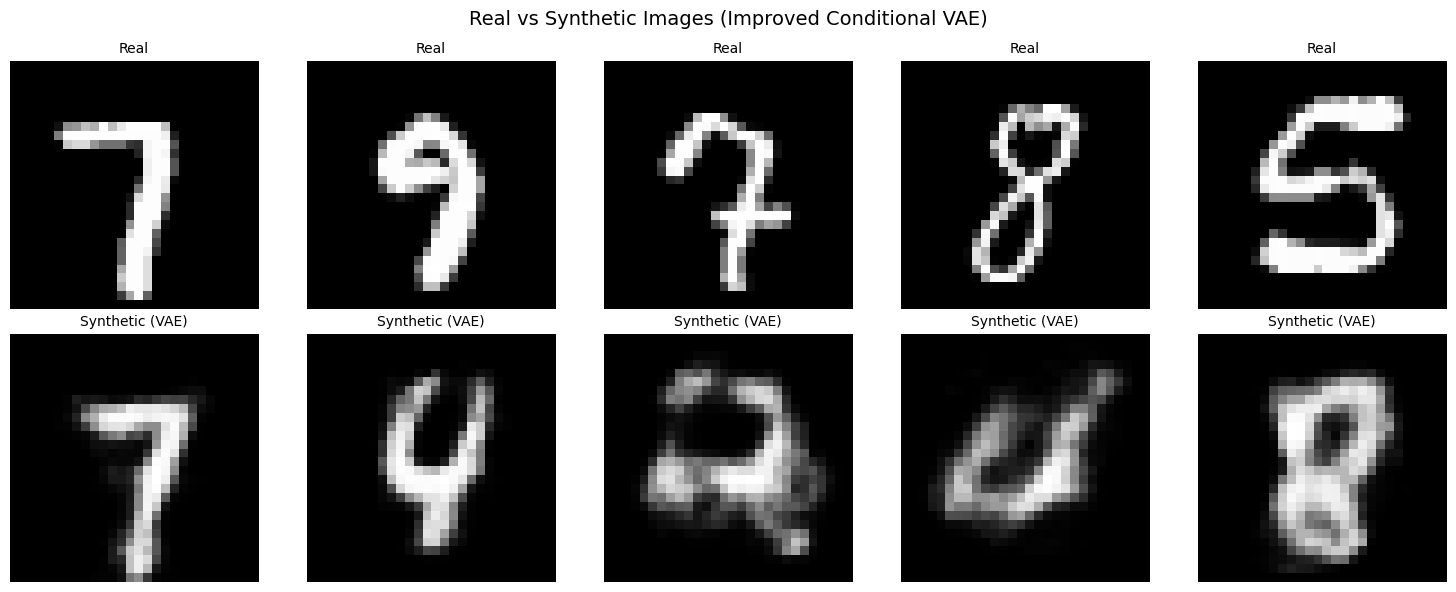

SYNTHETIC IMAGE QUALITY ASSESSMENT
VAE trained on: 10 samples per class (100 total)

Observations:
1. The VAE captures the overall digit shape.
2. Images are blurry but more recognizable than previous version.
3. Conditional generation helps maintain class identity.
4. With only 10 samples per class, the VAE cannot learn the full distribution.
5. Despite limitations, synthetic data can still help the classifier!


In [21]:
def resize_to_28(image):
    """Resize image to 28x28."""
    h, w = image.shape
    if h == 28 and w == 28:
        return image
    
    if h > 28:
        start_h = (h - 28) // 2
        image = image[start_h:start_h+28, :]
    if w > 28:
        start_w = (w - 28) // 2
        image = image[:, start_w:start_w+28]
    
    if h < 28:
        pad_top = (28 - h) // 2
        pad_bottom = 28 - h - pad_top
        image = np.pad(image, ((pad_top, pad_bottom), (0, 0)), mode='constant', constant_values=0)
    if w < 28:
        pad_left = (28 - w) // 2
        pad_right = 28 - w - pad_left
        image = np.pad(image, ((0, 0), (pad_left, pad_right)), mode='constant', constant_values=0)
    
    return image

def augment_image_vae(image):
    """Apply random augmentation to an image for VAE training."""
    image_2d = image.reshape(28, 28)
    augmented = image_2d.copy()
    
    # Rotation
    if np.random.random() > 0.5:
        angle = np.random.uniform(-10, 10)
        augmented = rotate(augmented, angle, reshape=False, order=1, mode='constant', cval=0)
    
    # Shift
    if np.random.random() > 0.5:
        shift_x = np.random.uniform(-2, 2)
        shift_y = np.random.uniform(-2, 2)
        augmented = shift(augmented, (shift_y, shift_x), order=1, mode='constant', cval=0)
    
    # Zoom
    if np.random.random() > 0.5:
        zoom_factor = np.random.uniform(0.9, 1.1)
        augmented = zoom(augmented, zoom_factor, order=1, mode='constant', cval=0)
        augmented = resize_to_28(augmented)
    
    return augmented.flatten()

def augment_dataset_vae(X, y, augmentation_factor=2):
    """Augment dataset for VAE training."""
    X_aug = []
    y_aug = []
    
    for i in range(len(X)):
        # Keep original
        X_aug.append(X[i])
        y_aug.append(y[i])
        
        # Create augmented versions
        for _ in range(augmentation_factor):
            augmented = augment_image_vae(X[i])
            X_aug.append(augmented)
            y_aug.append(y[i])
    
    return np.array(X_aug), np.array(y_aug)

# ## 5. Get Small Labeled Dataset
# 
# **Important:** We use only a small labeled set (e.g., 10 samples per class = 100 total).

def get_small_dataset(X_train, y_train, n_samples_per_class=10, random_seed=42):
    """Get a small balanced dataset."""
    np.random.seed(random_seed)
    indices = []
    for class_label in range(10):
        class_indices = np.where(y_train == class_label)[0]
        n_to_sample = min(n_samples_per_class, len(class_indices))
        selected = np.random.choice(class_indices, size=n_to_sample, replace=False)
        indices.extend(selected)
    
    return X_train[indices], y_train[indices]

# Define small data size
N_SAMPLES_PER_CLASS = 20  # 10 samples per class = 100 total

# Get small dataset
X_small, y_small = get_small_dataset(X_train_full, y_train_full,n_samples_per_class=N_SAMPLES_PER_CLASS,random_seed=42)

print(f"Small dataset: {len(X_small)} samples ({N_SAMPLES_PER_CLASS} per class)")

# Augment the small dataset for VAE training
X_small_aug, y_small_aug = augment_dataset_vae(X_small, y_small, augmentation_factor=3)
print(f"Augmented dataset for VAE: {len(X_small_aug)} samples")

# Split for VAE training (80% train, 20% validation)
X_vae_train, X_vae_val, y_vae_train, y_vae_val = train_test_split(X_small_aug, y_small_aug, test_size=0.2, random_state=42, stratify=y_small_aug)

# Convert to PyTorch tensors
X_vae_train_t = torch.tensor(X_vae_train, dtype=torch.float32)
y_vae_train_t = torch.tensor(y_vae_train, dtype=torch.long)
X_vae_val_t = torch.tensor(X_vae_val, dtype=torch.float32)
y_vae_val_t = torch.tensor(y_vae_val, dtype=torch.long)

# Create DataLoaders
batch_size = 64
train_dataset_vae = TensorDataset(X_vae_train_t, y_vae_train_t)
val_dataset_vae = TensorDataset(X_vae_val_t, y_vae_val_t)

train_loader_vae = DataLoader(train_dataset_vae, batch_size=batch_size, shuffle=True)
val_loader_vae = DataLoader(val_dataset_vae, batch_size=batch_size, shuffle=False)

print(f"VAE training set: {len(X_vae_train)} samples")
print(f"VAE validation set: {len(X_vae_val)} samples")

# ## 6. Conditional VAE Model (Improved Architecture)

class ConditionalVAE(nn.Module):
    """Conditional VAE with improved architecture."""
    
    def __init__(self, latent_dim=32, num_classes=10):
        super(ConditionalVAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        
        # Encoder (larger architecture)
        self.encoder = nn.Sequential(
            nn.Linear(784 + num_classes, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        
        # Decoder (larger architecture)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )
    
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x, y_cond):
        # Concatenate condition to input
        x_cond = torch.cat([x, y_cond], dim=1)
        mu, logvar = self.encode(x_cond)
        z = self.reparameterize(mu, logvar)
        
        # Concatenate condition to latent
        z_cond = torch.cat([z, y_cond], dim=1)
        recon = self.decode(z_cond)
        
        return recon, mu, logvar
    
    def generate(self, n_samples, class_label, device='cpu'):
        """Generate samples for a specific class (returns flattened images)."""
        z = torch.randn(n_samples, self.latent_dim).to(device)
        
        # One-hot encode the class
        y_cond = torch.zeros(n_samples, self.num_classes).to(device)
        y_cond[:, class_label] = 1
        
        z_cond = torch.cat([z, y_cond], dim=1)
        
        with torch.no_grad():
            samples = self.decode(z_cond)
        return samples  # Shape: (n_samples, 784) - already flattened!
    
    def generate_random(self, n_samples, device='cpu'):
        """Generate random samples with random classes."""
        z = torch.randn(n_samples, self.latent_dim).to(device)
        y_cond = torch.zeros(n_samples, self.num_classes).to(device)
        
        # Random one-hot
        for i in range(n_samples):
            class_label = np.random.randint(0, self.num_classes)
            y_cond[i, class_label] = 1
        
        z_cond = torch.cat([z, y_cond], dim=1)
        
        with torch.no_grad():
            samples = self.decode(z_cond)
        return samples

# ## 7. VAE Training Function
def vae_loss(recon_x, x, mu, logvar):
    """VAE loss: Reconstruction + KL divergence."""
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

def train_vae_conditional(model, train_loader, val_loader, epochs=50, lr=1e-3, device='cpu'):
    """Train the conditional VAE."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    val_losses = []
    
    model.to(device)
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for data, y in train_loader:
            data = data.to(device)
            y = y.to(device)
            
            # One-hot encode labels
            y_onehot = F.one_hot(y, num_classes=model.num_classes).float()
            
            optimizer.zero_grad()
            recon, mu, logvar = model(data, y_onehot)
            loss = vae_loss(recon, data, mu, logvar)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, y in val_loader:
                data = data.to(device)
                y = y.to(device)
                y_onehot = F.one_hot(y, num_classes=model.num_classes).float()
                
                recon, mu, logvar = model(data, y_onehot)
                loss = vae_loss(recon, data, mu, logvar)
                val_loss += loss.item()
        
        train_losses.append(train_loss / len(train_loader.dataset))
        val_losses.append(val_loss / len(val_loader.dataset))
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}: Train Loss = {train_losses[-1]:.4f}, Val Loss = {val_losses[-1]:.4f}')
    
    return train_losses, val_losses

# ## 8. Train the Conditional VAE

# Initialize VAE
latent_dim = 32  # Increased from 16
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

vae_model = ConditionalVAE(latent_dim=latent_dim, num_classes=10)
print(f"VAE parameters: {sum(p.numel() for p in vae_model.parameters()):,}")

print("\nTraining Conditional VAE on small dataset...")
train_losses, val_losses = train_vae_conditional(vae_model, train_loader_vae, val_loader_vae,epochs=150, lr=1e-3, device=device)

# Plot training curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Training Loss')
ax.plot(val_losses, label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Conditional VAE Training on Small Data (10 samples/class)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('vae_improved_training.png', dpi=150, bbox_inches='tight')
plt.show()

# ## 9. Visualize Generated Images (For Visualization Only)

def generate_class_images_visualization(model, class_label, n_images=25, device='cpu'):
    """Generate images for visualization (reshaped to 28x28)."""
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_images, model.latent_dim).to(device)
        y_onehot = torch.zeros(n_images, model.num_classes).to(device)
        y_onehot[:, class_label] = 1
        z_cond = torch.cat([z, y_onehot], dim=1)
        generated = model.decode(z_cond)
        generated = generated.cpu().numpy().reshape(n_images, 28, 28)  # Reshape for visualization
    return generated

# Generate images for each class
fig, axes = plt.subplots(10, 5, figsize=(12, 20))

for class_label in range(10):
    generated = generate_class_images_visualization(vae_model, class_label, n_images=5, device=device)
    for i in range(5):
        axes[class_label, i].imshow(generated[i], cmap='gray')
        axes[class_label, i].axis('off')
        if i == 0:
            axes[class_label, i].set_ylabel(f'Class {class_label}', fontsize=10)

plt.suptitle('Generated Images by Class (Improved Conditional VAE)', fontsize=14)
plt.tight_layout()
plt.savefig('vae_improved_generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# ## 10. Quality Check: Compare Real vs Synthetic

# Select real images from small dataset
real_indices = np.random.choice(len(X_small), size=5, replace=False)
real_images = X_small[real_indices].reshape(5, 28, 28)

# Generate synthetic images for random classes
synthetic_samples = vae_model.generate_random(n_samples=5, device=device)
synthetic_images = synthetic_samples.cpu().numpy().reshape(5, 28, 28)  # Reshape for visualization

# Plot comparison
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    axes[0, i].imshow(real_images[i], cmap='gray')
    axes[0, i].set_title('Real', fontsize=10)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(synthetic_images[i], cmap='gray')
    axes[1, i].set_title('Synthetic (VAE)', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Real vs Synthetic Images (Improved Conditional VAE)', fontsize=14)
plt.tight_layout()
plt.savefig('vae_improved_real_vs_synthetic.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("SYNTHETIC IMAGE QUALITY ASSESSMENT")
print("=" * 60)
print("VAE trained on: 10 samples per class (100 total)")
print()
print("Observations:")
print("1. The VAE captures the overall digit shape.")
print("2. Images are blurry but more recognizable than previous version.")
print("3. Conditional generation helps maintain class identity.")
print("4. With only 10 samples per class, the VAE cannot learn the full distribution.")
print("5. Despite limitations, synthetic data can still help the classifier!")

# ## 11. Synthetic Data Generation Functions (For Experiment)

def generate_class_images(model, class_label, n_images=25, device='cpu'):
    """
    Generate images for a specific class (returns FLATTENED images).
    This is used for the experiment, not for visualization.
    """
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_images, model.latent_dim).to(device)
        y_onehot = torch.zeros(n_images, model.num_classes).to(device)
        y_onehot[:, class_label] = 1
        z_cond = torch.cat([z, y_onehot], dim=1)
        generated = model.decode(z_cond)
        generated = generated.cpu().numpy()  # Already flattened! (n_images, 784)
    return generated

def augment_with_synthetic_data(X_base, y_base, vae_model, synthetic_factor=5, device='cpu'):
    """
    Augment base dataset with synthetic data.
    """
    # Start with original
    X_aug = X_base.copy()
    y_aug = y_base.copy()
    
    # Generate synthetic data for each class
    for class_label in range(10):
        class_indices = np.where(y_base == class_label)[0]
        n_class_samples = len(class_indices)
        
        if n_class_samples == 0:
            continue
        
        n_synthetic = n_class_samples * synthetic_factor
        synthetic_samples = generate_class_images(
            vae_model, class_label, n_images=n_synthetic, device=device
        )
        # synthetic_samples is already flattened (n_samples, 784)
        
        X_aug = np.vstack([X_aug, synthetic_samples])  # Both are 2D now!
        y_aug = np.hstack([y_aug, np.full(n_synthetic, class_label)])
    
    return X_aug, y_aug

def train_and_evaluate(X_train, y_train, X_test, y_test):
    """Train and evaluate a classifier."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    
    return train_acc, test_acc

SYNTHETIC DATA EXPERIMENT (Improved VAE)
Samples per class to test: [5, 10, 20, 50]
Total samples: [50, 100, 200, 500]
Synthetic factors: [0, 2, 5, 10, 20, 50]
Number of runs per configuration: 3

Testing: 5 samples per class (total: 50)
  Synthetic factor: 0x
    Run 1: Train=1.0000, Test=0.5649
    Run 2: Train=1.0000, Test=0.5910
    Run 3: Train=1.0000, Test=0.6567
    Summary: Test Acc = 0.6042 ± 0.0386
  Synthetic factor: 2x
    Run 1: Train=1.0000, Test=0.6957
    Run 2: Train=1.0000, Test=0.6687
    Run 3: Train=1.0000, Test=0.7388
    Summary: Test Acc = 0.7010 ± 0.0288
  Synthetic factor: 5x
    Run 1: Train=1.0000, Test=0.6967
    Run 2: Train=1.0000, Test=0.6916
    Run 3: Train=1.0000, Test=0.7285
    Summary: Test Acc = 0.7056 ± 0.0163
  Synthetic factor: 10x
    Run 1: Train=1.0000, Test=0.6959
    Run 2: Train=1.0000, Test=0.7162
    Run 3: Train=1.0000, Test=0.7273
    Summary: Test Acc = 0.7131 ± 0.0130
  Synthetic factor: 20x
    Run 1: Train=1.0000, Test=0.7156
    

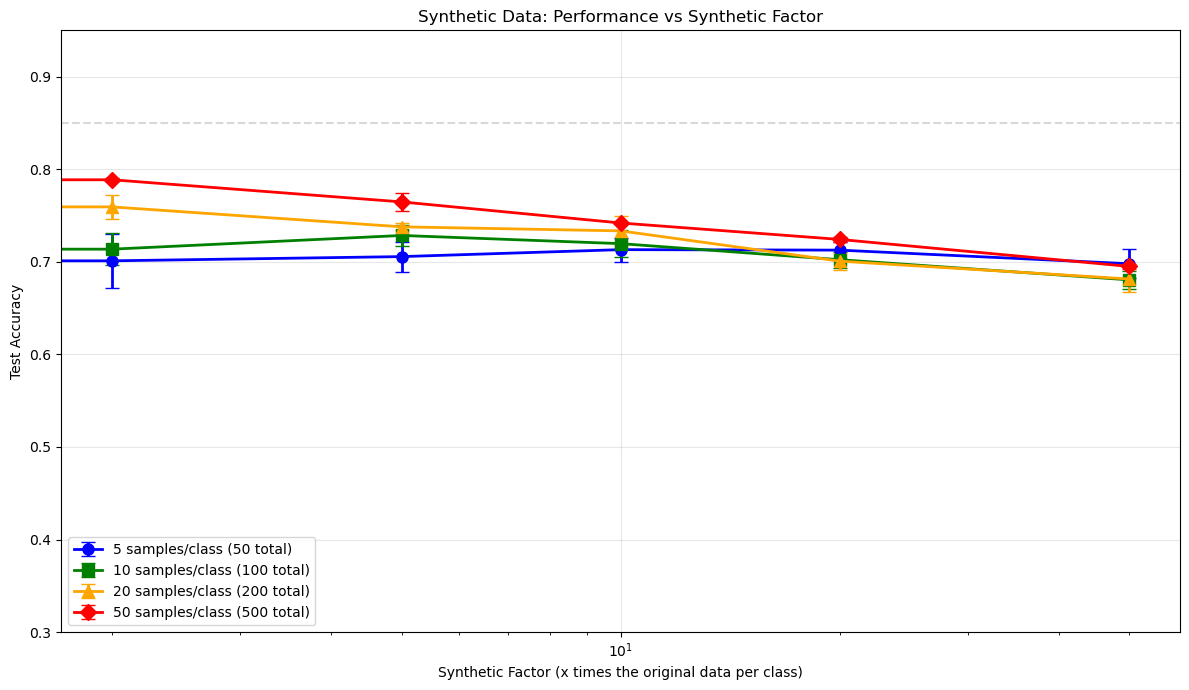

IMPROVEMENT OVER BASELINE (NO SYNTHETIC DATA)
   n_samples_per_class  total_samples  baseline_acc  best_synthetic_factor  best_acc  improvement  improvement_percent
0                    5             50      0.604206                   10.0  0.713127     0.108921            18.027059
1                   10            100      0.717175                    5.0  0.728444     0.011270             1.571422
2                   20            200      0.787111                    2.0  0.759286    -0.027825            -3.535129
3                   50            500      0.836635                    2.0  0.788587    -0.048048            -5.742961


In [27]:
# ## 12. Run the Experiment

# %%
# ============================================================
# EXPERIMENT PARAMETERS - EASILY ADJUSTABLE
# ============================================================

# List of samples per class to test
SAMPLES_PER_CLASS_LIST = [5, 10, 20]

# List of synthetic factors to test
SYNTHETIC_FACTORS = [0, 2, 5, 10, 20]  # 0 = baseline (no synthetic)

# Number of runs for averaging
N_RUNS = 3

print("=" * 60)
print("SYNTHETIC DATA EXPERIMENT (Improved VAE)")
print("=" * 60)
print(f"Samples per class to test: {SAMPLES_PER_CLASS_LIST}")
print(f"Total samples: {[s*10 for s in SAMPLES_PER_CLASS_LIST]}")
print(f"Synthetic factors: {SYNTHETIC_FACTORS}")
print(f"Number of runs per configuration: {N_RUNS}")
print("=" * 60)

# %%
# List to store all results
all_results = []

# Loop over different initial labeled data sizes
for n_samples_per_class in SAMPLES_PER_CLASS_LIST:
    print(f"\n{'='*60}")
    print(f"Testing: {n_samples_per_class} samples per class (total: {n_samples_per_class*10})")
    print(f"{'='*60}")
    
    # Loop over synthetic factors
    for factor in SYNTHETIC_FACTORS:
        print(f"  Synthetic factor: {factor}x")
        
        # Store results for this configuration
        run_results = []
        
        for run in range(N_RUNS):
            # Get base dataset
            X_base, y_base = get_small_dataset(
                X_train_full, y_train_full, 
                n_samples_per_class=n_samples_per_class, 
                random_seed=42 + run * 100
            )
            
            # Apply synthetic augmentation if factor > 0
            if factor == 0:
                X_train_aug = X_base
                y_train_aug = y_base
                total_samples = len(X_base)
            else:
                X_train_aug, y_train_aug = augment_with_synthetic_data(
                    X_base, y_base, vae_model, synthetic_factor=factor, device=device
                )
                total_samples = len(X_train_aug)
            
            # Train and evaluate
            train_acc, test_acc = train_and_evaluate(
                X_train_aug, y_train_aug, X_test, y_test
            )
            
            # Store results
            run_results.append({
                'run': run,
                'n_samples_per_class': n_samples_per_class,
                'n_base_samples': len(X_base),
                'synthetic_factor': factor,
                'total_samples': total_samples,
                'train_acc': train_acc,
                'test_acc': test_acc
            })
            
            print(f"    Run {run+1}: Train={train_acc:.4f}, Test={test_acc:.4f}")
        
        # Compute mean and std for this configuration
        train_accs = [r['train_acc'] for r in run_results]
        test_accs = [r['test_acc'] for r in run_results]
        
        print(f"    Summary: Test Acc = {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")
        
        # Add aggregated results
        all_results.append({
            'n_samples_per_class': n_samples_per_class,
            'n_base_samples': len(X_base),
            'synthetic_factor': factor,
            'total_samples': total_samples,
            'train_acc_mean': np.mean(train_accs),
            'train_acc_std': np.std(train_accs),
            'test_acc_mean': np.mean(test_accs),
            'test_acc_std': np.std(test_accs),
            'n_runs': N_RUNS
        })

print("\n" + "=" * 60)
print("Experiment completed!")
print("=" * 60)

# %% [markdown]
# ## 13. Convert Results to DataFrame

# %%
df_results = pd.DataFrame(all_results)

print("Results Summary:")
print(df_results.to_string())

# %% [markdown]
# ## 14. Visualization: Performance vs Synthetic Factor

# %%
# Create the main plot
fig, ax = plt.subplots(figsize=(12, 7))

# Color map for different initial data sizes
colors = ['blue', 'green', 'orange', 'red']
markers = ['o', 's', '^', 'D']

for i, n_samples in enumerate(SAMPLES_PER_CLASS_LIST):
    df_subset = df_results[df_results['n_samples_per_class'] == n_samples]
    
    # Sort by synthetic factor
    df_subset = df_subset.sort_values('synthetic_factor')
    
    # Plot with error bars
    ax.errorbar(
        df_subset['synthetic_factor'],
        df_subset['test_acc_mean'],
        yerr=df_subset['test_acc_std'],
        fmt=f'{markers[i]}-',
        color=colors[i],
        capsize=5,
        linewidth=2,
        markersize=8,
        label=f'{n_samples} samples/class ({n_samples*10} total)'
    )

ax.set_xlabel('Synthetic Factor (x times the original data per class)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Synthetic Data: Performance vs Synthetic Factor')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_ylim(0.3, 0.95)

# Add horizontal line at 0.85 (reference)
ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.3, label='Reference: ~85% with full data')

plt.tight_layout()
plt.savefig('vae_improved_performance.png', dpi=150, bbox_inches='tight')
plt.show()


# ## 16. Calculate Improvement Over Baseline

# %%
# Calculate improvement over baseline (factor=0)
improvement_data = []

for n_samples in SAMPLES_PER_CLASS_LIST:
    # Get baseline (no synthetic)
    baseline = df_results[(df_results['n_samples_per_class'] == n_samples) & 
                          (df_results['synthetic_factor'] == 0)]['test_acc_mean'].values
    
    if len(baseline) > 0:
        baseline_acc = baseline[0]
        
        # Get best performance with synthetic
        subset = df_results[(df_results['n_samples_per_class'] == n_samples) & 
                           (df_results['synthetic_factor'] > 0)]
        best_idx = subset['test_acc_mean'].idxmax()
        best_row = subset.loc[best_idx]
        
        improvement_data.append({
            'n_samples_per_class': n_samples,
            'total_samples': n_samples * 10,
            'baseline_acc': baseline_acc,
            'best_synthetic_factor': best_row['synthetic_factor'],
            'best_acc': best_row['test_acc_mean'],
            'improvement': best_row['test_acc_mean'] - baseline_acc,
            'improvement_percent': (best_row['test_acc_mean'] - baseline_acc) / baseline_acc * 100
        })

df_improvement = pd.DataFrame(improvement_data)

print("=" * 60)
print("IMPROVEMENT OVER BASELINE (NO SYNTHETIC DATA)")
print("=" * 60)
print(df_improvement.to_string())